In [1]:
import os
import math
import torch
from torch.nn.functional import softplus
from datetime import datetime
from tensorboardX import SummaryWriter
from equiv_dens.nn.neural_network_dens2 import NeuralNetwork
from equiv_dens.training.parse_command_line_arguments import parse_command_line_arguments
from equiv_dens.training.util import generate_id, empty_error_dict, compute_error_dict
from equiv_dens.training.density_dataset import AtomsDensityData
from equiv_dens.training.hamiltonian_dataset import seeded_random_split
from equiv_dens.training.exponential_moving_average import ExponentialMovingAverage
from equiv_dens.training.lookahead import Lookahead
from equiv_dens.training.batch_loader import BatchLoader
from equiv_dens.nn.modules.spherical_harmonics_expansion import SphericalHarmonicsExpansion

import numpy as np
import time
from functools import partial
from equiv_dens.training.grids import cubical_grid, cubical_sampling, dftpy_grid, CubicalGrid
from equiv_dens.nn.density_functionals.LDA import LDAFunctional

from dftpy.field import *
from dftpy.grid import *
from dftpy.functionals import FunctionalClass, TotalEnergyAndPotential
from dftpy.pseudo import LocalPseudo
from dftpy.formats import io, ase_io
from dftpy.math_utils import bestFFTsize
from dftpy.time_data import TimeData
from dftpy.optimization import Optimization
from dftpy.constants import LEN_CONV, ENERGY_CONV
from dftpy.system import System
import ase.io
import ml_dft.dft_utils as du
%load_ext autoreload
%autoreload 2

Use "numpy" for Fourier Transform


In [2]:
#directory = '2020-08-20_LuCuJBCl'  # load directory name
#model_name = 'LuCuJBCl'
# sq model
# directory = '2020-09-23_gtvoM9WL'  # load directory name
# model_name = 'gtvoM9WL'
# balance 1
# directory = '2020-09-28_YxazEPiG'  # load directory name
# model_name = 'YxazEPiG'
# balance 2
# directory = '2020-11-25_on882Qq5'  # load directory name
# model_name = 'on882Qq5'
# sp no integral model
# directory = '2020-11-24_twjvvsD8/'  # load directory name
# model_name = 'twjvvsD8'
# sp integral model
#directory = '2020-11-25_vO2qku3v/'  # load directory name
#model_name = 'vO2qku3v'
# sp integral model static
directory = '2020-12-01_jPoYYuxC/'  # load directory name
model_name = 'jPoYYuxC'

#directory = '2020-04-30_To0wdEze'
checkpoint_dir = os.path.join(
    directory, 'checkpoints')  # checkpoint directory
# load latest checkpoint
checkpoint = torch.load(os.path.join(
    checkpoint_dir, 'latest_checkpoint.pth'), map_location='cpu')
latest_checkpoint = checkpoint['epoch']
ID = checkpoint['ID']  # load ID
args = checkpoint['args']  # overwrite args
args.use_gpu = False
#args.load_from = os.path.join(directory, 'best_' + model_name + '.pth')
if args.use_gpu:
    device = 'cuda'
else:
    device = 'cpu'

In [3]:
grid_origin = -2.0318
cube_grid_fn = partial(cubical_grid, nx=args.cube_size, ny=args.cube_size, nz=args.cube_size,
                       extent=np.array([4.1483, 4.1483, 4.1483]),
                       origin=np.array([-2.0318, -2.0318, -2.0318]))
cube_sampling_fn = cubical_sampling


valid_cube_dataset = AtomsDensityData(np_path=args.np_dataset, density_path=args.dens_dataset,
                           orbitals_path=args.orbitals_file,
                           density_n_samp=10000000000,
                           required_properties=['density', 'energy'],
                           center_positions=False,
                           radial_coeffs_file=args.radial_coeffs_file,
                           dtype=args.dtype,
                           grid_fn=cube_grid_fn,
                           sampling_fn=cube_sampling_fn,
                           grid_extent=np.array([4.1483, 4.1483, 4.1483]),
                           grid_origin=grid_origin)


grid_cl = CubicalGrid(None, nx=args.cube_size, ny=args.cube_size, nz=args.cube_size,
                      origin=[0, 0, 0], extent=du.angstrom_to_bohr(np.array([4.1483, 4.1483, 4.1483])), device=device, dtype=args.dtype)

gap = 0.4
grid = dftpy_grid(np.diag(du.angstrom_to_bohr(np.array([4.1483, 4.1483, 4.1483]))), 0.4)
# print('grid.lattice', grid.lattice)
# print('grid size', grid.r.shape)
# print('ions lattice', dataset.ions[0].pos.cell.lattice)

file_names = {'H': 'H.pbe-kjpaw_psl.0.1.UPF', 'C': 'C.pbe-kjpaw_psl.0.1.UPF',
              'O': 'O.pbe-n-kjpaw_psl.0.1.UPF'}
PP_list = {key: os.path.join(args.pseudo_pot_path, file_names[key]) for key in file_names.keys()}
# print('pseudo potentials', PP_list)
pseudo_pot = LocalPseudo(grid=grid, ions=None, PP_list=PP_list, PME=True)
pseudo_pot.restart(grid=grid, ions=valid_cube_dataset.ions[0])


Starting atomsdata density init
Some variables
atoms keys dict_keys(['positions', 'hamiltonians', 'overlaps', 'basidef', 'nonzero_indices', 'atom_types', 'atom_numbers', 'energy'])
finished init
The initial grid size is  [19 19 19]
The final grid size is  [20 20 20]
setting key: H
setting key: C
setting key: O


In [4]:
loss_weights = {}
loss_weights['density'] = args.density_weight
loss_weights['energy'] = args.energy_weight

valid_cube_sampler = torch.utils.data.BatchSampler(torch.utils.data.RandomSampler(valid_cube_dataset),
                                                   batch_size=args.valid_batch_size, drop_last=False)
valid_cube_loader = BatchLoader(valid_cube_dataset, batch_sampler=valid_cube_sampler,
                                num_workers=args.num_workers, pin_memory=args.use_gpu)


In [5]:
cube_iterator = iter(valid_cube_loader)

In [6]:
# define model
if args.load_from is None:
    equiv_model = NeuralNetwork(
        orbitals=valid_cube_dataset.orbitals,
        order=args.order,
        num_features=args.num_features,
        num_basis_functions=args.num_basis_functions,
        num_modules=args.num_modules,
        num_residual_pre_x=args.num_residual_pre_x,
        num_residual_post_x=args.num_residual_post_x,
        num_residual_pre_vi=args.num_residual_pre_vi,
        num_residual_pre_vj=args.num_residual_pre_vj,
        num_residual_post_v=args.num_residual_post_v,
        num_residual_output=args.num_residual_output,
        num_radial_components=args.num_radial_components,
        basis_functions=args.basis_functions,
        cutoff=args.cutoff,
        positive_coeffs=args.positive_coeffs,
        activation=args.activation)
    expansion_model = SphericalHarmonicsExpansion(valid_cube_dataset.orbitals,
                                                  radial_coeffs=valid_cube_dataset.radial_coeffs,
                                                  expansion_constraint=args.expansion_constraint,
                                                  integral_constraint=args.integral_constraint,
                                                  verbose=args.verbose,
                                                  softmax_norm=args.softmax_norm)
else:
    equiv_model = NeuralNetwork(load_from=args.load_from)
    expansion_model = SphericalHarmonicsExpansion(valid_cube_dataset.orbitals,
                                                  radial_coeffs=valid_cube_dataset.radial_coeffs,
                                                  expansion_constraint=args.expansion_constraint,
                                                  integral_constraint=args.integral_constraint,
                                                  verbose=args.verbose,
                                                  softmax_norm=args.softmax_norm)

z_vals = []
print('ions0', valid_cube_dataset.ions[0])
for t in valid_cube_dataset.atoms['atom_types']:
    z_vals.append(valid_cube_dataset.ions[0].Zval[t])
z_vals = np.array(z_vals)
print(valid_cube_dataset.atoms['atom_numbers'])
print(z_vals)
lda = LDAFunctional(z_vals, verbose=args.verbose)    

# convert the model to the correct dtype
equiv_model.to(args.dtype)
expansion_model.to(args.dtype)
lda.to(args.dtype)
# send model to GPU (if use_gpu is True)
if args.use_gpu:
    equiv_model.cuda()
    expansion_model.cuda()

print('weights balancing', args.weights_balance)

An orbital with L=5 was found, but the neural network was initialized with L=6
The neural network SHOULD have at least twice the order of the maximum order orbital for good results!
orbital_spec [[(8, 11, 0), (8, 8, 1), (8, 6, 2), (8, 4, 3), (8, 3, 4), (8, 2, 5)], [(1, 5, 0), (1, 4, 1), (1, 4, 2), (1, 3, 3), (1, 2, 4)], [(1, 5, 0), (1, 4, 1), (1, 4, 2), (1, 3, 3), (1, 2, 4)]]
cg_matrix shape torch.Size([121, 121, 121])
L_counts [16, 12, 10, 7, 5, 2, 0, 0, 0, 0, 0, 0, 0]
L_dict {(8, 0): range(0, 11), (8, 1): range(0, 8), (8, 2): range(0, 6), (8, 3): range(0, 4), (8, 4): range(0, 3), (8, 5): range(0, 2), (1, 0): range(11, 16), (1, 1): range(8, 12), (1, 2): range(6, 10), (1, 3): range(4, 7), (1, 4): range(3, 5)}
max lcounts 16
ions0                 Zval : {'H': 1.0, 'C': 4.0, 'O': 6.0}
                 pos : [[3.83954554 3.83954554 3.83954554]
 [5.67121512 3.64632177 3.83954554]
 [3.64632177 5.67121512 3.83954554]]
                 nat : 3
                   Z : [8 1 1]
              labe

In [7]:
equiv_module = equiv_model
expansion_module = expansion_model

# for keeping an exponential moving average of the model parameters (usually leads to better models)
if checkpoint is not None:  # no checkpoint is specified
    step = checkpoint['step']
    epoch = checkpoint['epoch']
    best_errors = checkpoint['best_errors']
    valid_errors = checkpoint['valid_errors']
    equiv_module.load_state_dict(checkpoint['model_state_dict'])
# or initialize step / epoch to 0 and errors to infinity
else:
    step = 0
    epoch = 0
    best_errors = empty_error_dict(loss_weights, fill_value=math.inf)
    valid_errors = empty_error_dict(loss_weights, fill_value=math.inf)



In [8]:
print('best errors', best_errors)
print('valid_errors', valid_errors)

best errors {'loss': 135.16696166992188, 'energy_mae': 135.16696166992188, 'energy_rmse': 135.16696166992188}
valid_errors {'loss': 135.16696166992188, 'energy_mae': 135.16696166992188, 'energy_rmse': 135.16696166992188}


<IPython.core.display.Javascript object>


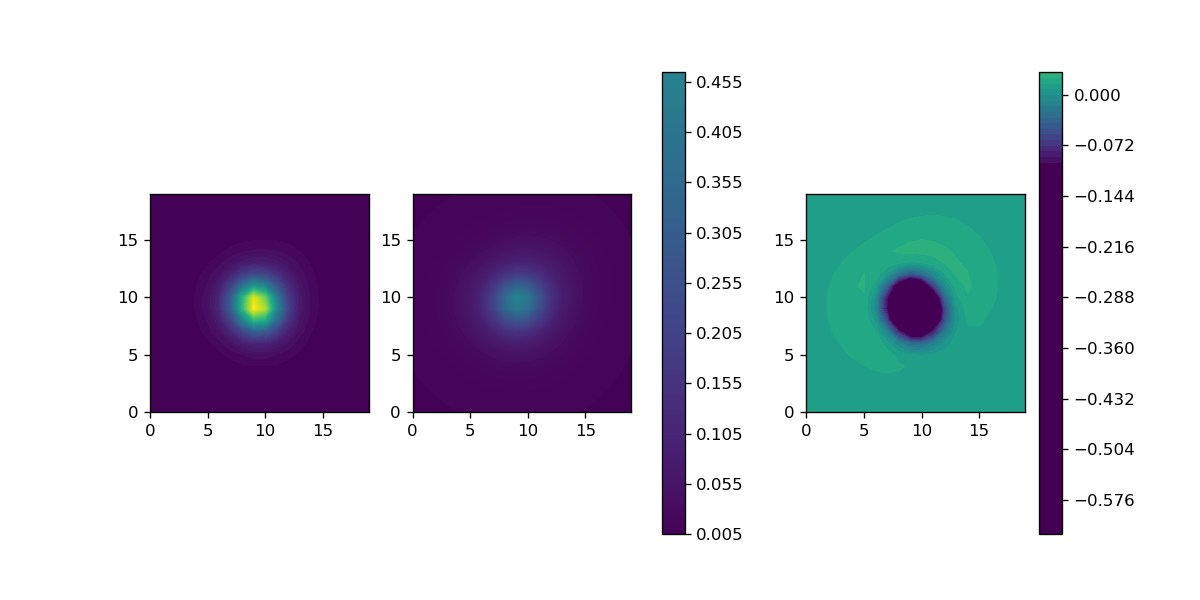

dens shape (8000,)
idx [   8  408  808 1208 1608 2008 2408 2808 3208 3608 4008 4408 4808 5208
 5608 6008 6408 6808 7208 7608   28  428  828 1228 1628 2028 2428 2828
 3228 3628 4028 4428 4828 5228 5628 6028 6428 6828 7228 7628   48  448
  848 1248 1648 2048 2448 2848 3248 3648 4048 4448 4848 5248 5648 6048
 6448 6848 7248 7648   68  468  868 1268 1668 2068 2468 2868 3268 3668
 4068 4468 4868 5268 5668 6068 6468 6868 7268 7668   88  488  888 1288
 1688 2088 2488 2888 3288 3688 4088 4488 4888 5288 5688 6088 6488 6888
 7288 7688  108  508  908 1308 1708 2108 2508 2908 3308 3708 4108 4508
 4908 5308 5708 6108 6508 6908 7308 7708  128  528  928 1328 1728 2128
 2528 2928 3328 3728 4128 4528 4928 5328 5728 6128 6528 6928 7328 7728
  148  548  948 1348 1748 2148 2548 2948 3348 3748 4148 4548 4948 5348
 5748 6148 6548 6948 7348 7748  168  568  968 1368 1768 2168 2568 2968
 3368 3768 4168 4568 4968 5368 5768 6168 6568 6968 7368 7768  188  588
  988 1388 1788 2188 2588 2988 3388 3788 4188 4588 498

/home/mihail/anaconda3/envs/equiv_dens/lib/python3.7/site-packages/torch/nn/functional.py:1628: UserWarning: nn.functional.tanh is deprecated. Use torch.tanh instead.
  warnings.warn("nn.functional.tanh is deprecated. Use torch.tanh instead.")


pred density shape torch.Size([1, 8000])
pred density integral tensor(11.9914, grad_fn=<SumBackward0>)
L tensor([7.8392, 7.8392, 7.8392])
charges tensor([6., 1., 1., 6., 1., 1., 6., 1., 1., 6., 1., 1., 6., 1., 1., 6., 1., 1.,
        6., 1., 1., 6., 1., 1., 6., 1., 1., 6., 1., 1., 6., 1., 1., 6., 1., 1.,
        6., 1., 1., 6., 1., 1., 6., 1., 1., 6., 1., 1., 6., 1., 1., 6., 1., 1.,
        6., 1., 1., 6., 1., 1., 6., 1., 1., 6., 1., 1., 6., 1., 1., 6., 1., 1.,
        6., 1., 1., 6., 1., 1., 6., 1., 1.])
predicted energy tensor(-9.3356, grad_fn=<AddBackward0>)


In [9]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib notebook
sample = 8
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(131)
dens = np.array(valid_cube_dataset[sample]['density'].squeeze())
print('dens shape', dens.shape)
x, y  = np.meshgrid(np.arange(args.cube_size), np.arange(args.cube_size))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + np.round((args.cube_size * 0.8)/2).astype(np.int)
idx = np.ravel_multi_index((x_f, y_f, z_f), (args.cube_size, args.cube_size, args.cube_size))
                
#X, Y, Z = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38, np.arange(50) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))

print('idx', idx)
dens2d = dens[idx]
dens2d = dens2d.reshape(args.cube_size, args.cube_size)

indices = np.stack((x_f, y_f, z_f), axis=1)
coords_space = valid_cube_dataset[sample]['coords']
print('coords space shape', coords_space.shape)
vmin = np.min(dens2d)
vmax = np.max(dens2d)
c1 = ax1.contourf(x, y, dens2d, vmin=vmin, vmax=vmax, levels=100)
ax1.set_aspect('equal')

positions = valid_cube_dataset[sample]['positions']
if args.use_gpu:
    positions = positions.cuda()
    coords_space = coords_space.cuda()

print('pos shape', valid_cube_dataset[[sample]]['positions'].shape)
print('positions', positions)
print('coords', coords_space)
coeffs = equiv_model(R=positions)
#print('sph coeffs', coeffs['spherical_coeffs'])

pred_dens = expansion_model(coords_space, positions,
                            coeffs['spherical_coeffs'],
                            coeffs['radial_width'],
                            coeffs['radial_scale'])



print('pred density shape', pred_dens['density'].shape)
print('pred density integral', torch.sum(pred_dens['density'] * valid_cube_dataset[sample]['coord_weights']))
p_dens = pred_dens['density'].cpu().data.squeeze().numpy()
p_dens = p_dens[idx].reshape(args.cube_size, args.cube_size)
pseudo_pot.restart(grid=grid, ions=valid_cube_dataset[sample]['ions'][0])
pred_en = lda(pred_dens['density'].view((args.cube_size, args.cube_size, args.cube_size)),
                            grid_cl, positions[0] - grid_origin, pseudo_pot)
print('predicted energy', pred_en)

ax2 = fig.add_subplot(132)
c2 = ax2.contourf(x, y, p_dens, vmin=vmin, vmax=vmax, levels=100)
ax2.set_aspect('equal')

ax3 = fig.add_subplot(133)
c3 = ax3.contourf(x, y, p_dens-dens2d, vmin=-0.1, vmax=0.1, levels=100)
ax3.set_aspect('equal')

fig.colorbar(c2, ax=[ax1, ax2])
fig.colorbar(c3, ax=[ax3])
plt.show()

In [10]:

pos = valid_cube_dataset[sample]['positions']
print('positions', pos)
coords = valid_cube_dataset[sample]['coords']
weights = valid_cube_dataset[sample]['coord_weights']
print('weights', weights)
print('coords shape', coords.shape)
dens_true = valid_cube_dataset[sample]['density']
print('density.shape', dens_true.shape)
print('density_integral', torch.sum(dens_true * weights))
dens_true_integral = torch.sum(dens_true * weights)
coeffs = equiv_model(R=pos)
dens_pred = expansion_model(coords, pos,
                            coeffs['spherical_coeffs'],
                            coeffs['radial_width'],
                            coeffs['radial_scale'])
dens_pred = dens_pred['density']
dens_pred_integral = torch.sum(dens_pred * weights)
dens_diff_integral = torch.sum(torch.abs(dens_pred - dens_true) * weights)
print('density pred integral', dens_pred_integral)
print('density_difference integral', dens_diff_integral)
print('density integral ratio', dens_diff_integral/dens_true_integral)

positions tensor([[[ 0.0000,  0.0000,  0.0000],
         [ 0.5569,  0.6854,  0.4123],
         [-0.7365, -0.0723,  0.6343]]])
weights tensor([0.0602, 0.0602, 0.0602,  ..., 0.0602, 0.0602, 0.0602])
coords shape torch.Size([1, 8000, 3])
density.shape torch.Size([1, 8000])
density_integral tensor(7.8253)
density pred integral tensor(11.9914, grad_fn=<SumBackward0>)
density_difference integral tensor(8.2424, grad_fn=<SumBackward0>)
density integral ratio tensor(1.0533, grad_fn=<DivBackward0>)


In [11]:
def MakeGrid(metric,gap):
    nr = np.zeros(3, dtype = 'int32')
    for i in range(3):
        nr[i] = int(np.sqrt(metric[i, i])/gap)
    print('The initial grid size is ', nr)
    for i in range(3):
        nr[i] = bestFFTsize(nr[i])
    print('The final grid size is ', nr)
    grid = DirectGrid(lattice=lattice, nr=nr, units=None, full=False)
    return grid

def guess_rho(grid,ions):
    charge_total = 0.0
    zerosA = np.zeros(grid.nnr, dtype=float)
    rho_ini = DirectField(grid=grid, griddata_F=zerosA, rank=1)
    for i in range(ions.nat) :
        charge_total += ions.Zval[ions.labels[i]]
    rho_ini[:] = charge_total/ions.pos.cell.volume
    return rho_ini

In [12]:
data_dir = '/home/mihail/Documents/workspace/schnet-tfn/equiv_dens/datasets/'
data = np.load(data_dir + 'h2o_overlap_static_centered.npy', allow_pickle=True).item()
npy_pos = data['positions'][:10]
print('pos shape', npy_pos.shape)
ase_pos = du.npy_to_ase(npy_pos, data['atom_types'])
ions_list = []
for a in ase_pos:
    a.set_cell([4.1483, 4.1483, 4.1483])
    a.set_positions(a.positions + 2.0318)
    ions_list.append(ase_io.ase2ions(a))
    
for ions in ions_list:
    print(ions)
    
    
lattice = ions.pos.cell.lattice
metric = np.dot(lattice.T, lattice)

gap = 0.4
#gap = 0.155
grid = MakeGrid(metric,gap)

pos shape (10, 3, 3)
                Zval : {}
                 pos : [[3.83954554 3.83954554 3.83954554]
 [5.67121512 3.64632177 3.83954554]
 [3.64632177 5.67121512 3.83954554]]
                 nat : 3
                   Z : [8 1 1]
              labels : ['O' 'H' 'H']
                Zval : {}
                 pos : [[3.83954554 3.83954554 3.83954554]
 [5.67121512 3.70291571 3.70291571]
 [3.64632177 5.13473152 5.13473152]]
                 nat : 3
                   Z : [8 1 1]
              labels : ['O' 'H' 'H']
                Zval : {}
                 pos : [[3.83954554 3.83954554 3.83954554]
 [5.67121512 3.83954554 3.64632177]
 [3.64632177 3.83954554 5.67121512]]
                 nat : 3
                   Z : [8 1 1]
              labels : ['O' 'H' 'H']
                Zval : {}
                 pos : [[3.83954554 3.83954554 3.83954554]
 [5.67121512 3.64632177 3.83954554]
 [3.64632177 5.67121512 3.83954554]]
                 nat : 3
                   Z : [8 1 1]
            

torch.Size([20, 20, 20])


<IPython.core.display.Javascript object>


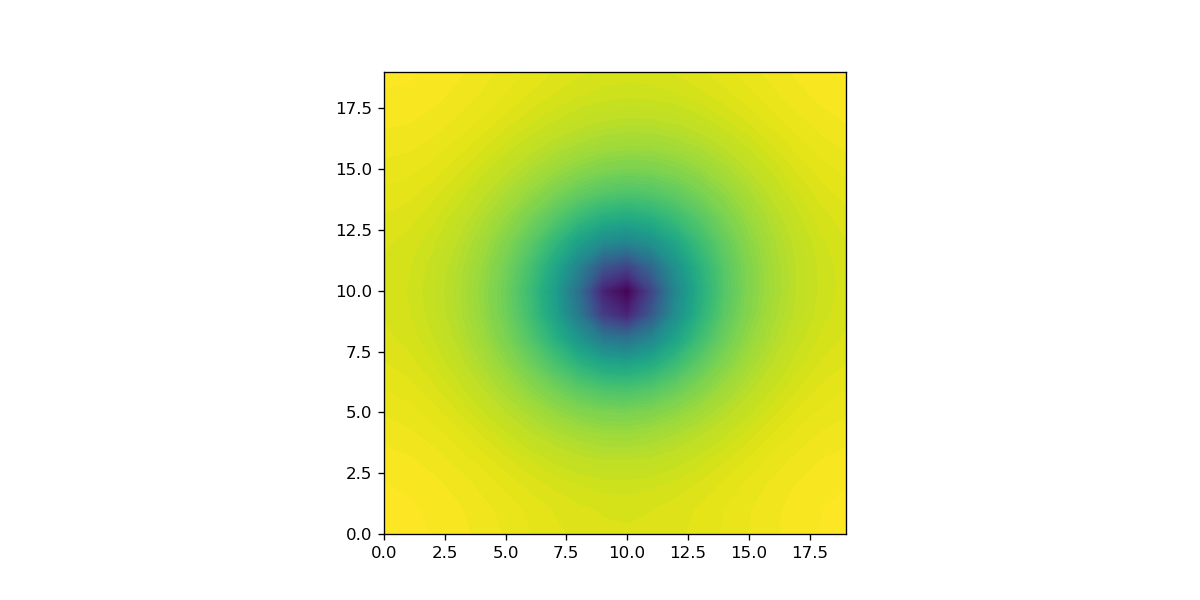

pseudo shape (8000,)
idx [   8  408  808 1208 1608 2008 2408 2808 3208 3608 4008 4408 4808 5208
 5608 6008 6408 6808 7208 7608   28  428  828 1228 1628 2028 2428 2828
 3228 3628 4028 4428 4828 5228 5628 6028 6428 6828 7228 7628   48  448
  848 1248 1648 2048 2448 2848 3248 3648 4048 4448 4848 5248 5648 6048
 6448 6848 7248 7648   68  468  868 1268 1668 2068 2468 2868 3268 3668
 4068 4468 4868 5268 5668 6068 6468 6868 7268 7668   88  488  888 1288
 1688 2088 2488 2888 3288 3688 4088 4488 4888 5288 5688 6088 6488 6888
 7288 7688  108  508  908 1308 1708 2108 2508 2908 3308 3708 4108 4508
 4908 5308 5708 6108 6508 6908 7308 7708  128  528  928 1328 1728 2128
 2528 2928 3328 3728 4128 4528 4928 5328 5728 6128 6528 6928 7328 7728
  148  548  948 1348 1748 2148 2548 2948 3348 3748 4148 4548 4948 5348
 5748 6148 6548 6948 7348 7748  168  568  968 1368 1768 2168 2568 2968
 3368 3768 4168 4568 4968 5368 5768 6168 6568 6968 7368 7768  188  588
  988 1388 1788 2188 2588 2988 3388 3788 4188 4588 4

In [13]:
dens = valid_cube_dataset[sample]['density'].view([args.cube_size, args.cube_size, args.cube_size])
print(dens.shape)
pseudo_pot.restart(grid=grid, ions=valid_cube_dataset[sample]['ions'][0])
pseudo_pot(dens)
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)
pot = np.array(pseudo_pot.vreal)
pot = pot.reshape((args.cube_size**3, ))
print('pseudo shape', pot.shape)
x, y  = np.meshgrid(np.arange(args.cube_size), np.arange(args.cube_size))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + np.round((args.cube_size * 0.8)/2).astype(np.int)
idx = np.ravel_multi_index((x_f, y_f, z_f), (args.cube_size, args.cube_size, args.cube_size))
                
#X, Y, Z = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38, np.arange(50) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))

print('idx', idx)
pot2d = pot[idx]
pot2d = pot2d.reshape(args.cube_size, args.cube_size)

indices = np.stack((x_f, y_f, z_f), axis=1)
vmin = np.min(pot2d)
vmax = np.max(pot2d)
c1 = ax1.contourf(x, y, pot2d, vmin=vmin, vmax=vmax, levels=100)
ax1.set_aspect('equal')

In [14]:
print('itegral = ', torch.sum(dens) * grid.dV)

itegral =  tensor(7.8253)


In [15]:
optional_kwargs = {}
KE = FunctionalClass(type='KEDF',name='x_TF_y_vW',optional_kwargs=optional_kwargs)
XC = FunctionalClass(type='XC',name='LDA')
HARTREE = FunctionalClass(type='HARTREE')

In [16]:
E_v_Evaluator = TotalEnergyAndPotential(KineticEnergyFunctional=KE,
                                XCFunctional=XC,
                                HARTREE=HARTREE,
                                PSEUDO=pseudo_pot)

In [41]:
from pyscf.lib import param
dens = valid_cube_dataset[sample]['density'].view([args.cube_size, args.cube_size, args.cube_size])
rho_data = guess_rho(grid, valid_cube_dataset[sample]['ions'][0])
rho_data[:] = dens.detach().numpy()
pseudo_pot.restart(grid=grid, ions=valid_cube_dataset[sample]['ions'][0])
Enew = E_v_Evaluator.Energy(rho=rho_data, ions=valid_cube_dataset[sample]['ions'][0], usePME = True)
print('dftpy en data dens', Enew)
pseudo_pot.restart(grid=grid, ions=valid_cube_dataset[sample]['ions'][0])
lda.verbose = 0
lda.ewald.verbose = 0
en = lda(dens, grid_cl, du.angstrom_to_bohr(valid_cube_dataset[sample]['positions'][0] - grid_origin), pseudo_pot)
print('dft net data dens', en)

Ewald : -4.510878055836248
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 32.882984778773704
evalfunctional XC
evalfunctional LDA
energy -5.053085900307887
evalfunctional HARTREE
evalfunctional HARTREE
energy 14.519683715046993
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -35.32479245535737
dftpy en data dens 2.513912082319191
L tensor([7.8392, 7.8392, 7.8392])
dft net data dens tensor(2.5139)


In [43]:
p_dens = pred_dens['density'].view([args.cube_size, args.cube_size, args.cube_size])
rho_pred = guess_rho(grid, valid_cube_dataset[sample]['ions'][0])
rho_pred[:] = p_dens.detach().numpy()
print(rho_pred.shape)
pseudo_pot.restart(grid=grid, ions=valid_cube_dataset[sample]['ions'][0])
Enew = E_v_Evaluator.Energy(rho=rho_pred, ions=valid_cube_dataset[sample]['ions'][0], usePME = True)
print('dftpy en pred dens', Enew)
pseudo_pot.restart(grid=grid, ions=valid_cube_dataset[sample]['ions'][0])

en = lda(p_dens, grid_cl, du.angstrom_to_bohr(valid_cube_dataset[sample]['positions'][0] - grid_origin), pseudo_pot)
print('dft net data dens', en)

(20, 20, 20)
Ewald : -4.510878055836248
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 10.531744350802262
evalfunctional XC
evalfunctional LDA
energy -4.381312477428757
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.460582498084574
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -23.39561587690141
dftpy en pred dens -15.295479561279578
L tensor([7.8392, 7.8392, 7.8392])
dft net data dens tensor(-15.2955, grad_fn=<AddBackward0>)


In [45]:
print(valid_cube_dataset[sample]['positions'])

tensor([[[ 0.0000,  0.0000,  0.0000],
         [ 0.5569,  0.6854,  0.4123],
         [-0.7365, -0.0723,  0.6343]]])


In [46]:
optimization_options = {\
        'econv' : 1e-6, # Energy Convergence (a.u./atom)
        'maxfun' : 50,  # For TN method, it's the max steps for searching direction
        'maxiter' : 100,# The max steps for optimization
        }
optimization_options["econv"] *= ions.nat
opt = Optimization(EnergyEvaluator=E_v_Evaluator, optimization_options = optimization_options,
        optimization_method = 'TN')


rho_ini = guess_rho(grid, valid_cube_dataset[sample]['ions'][0])
new_rho = opt.optimize_rho(guess_rho=rho_ini)


evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 1.4951353816791029
evalfunctional XC
evalfunctional LDA
energy -1.8371596242786334
evalfunctional HARTREE
evalfunctional HARTREE
energy 1.6779869639474494e-33
evalfunctional PSEUDO
evalfunctional PSEUDO
energy 0.05824582367476594
Step    Energy(a.u.)            dE              dP              Nd      Nls     Time(s)         
0       -2.837784189248E-01     -2.837784E-01   7.480619E+00    1       1       1.814413E-02    
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
!WARN: Change to steepest decent
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 1.6071433347576944
evalfunctional XC
evalfunctional LDA
energy -1.8547147596571618
evalfunctional HARTREE
evalfunctional HARTREE
energy 0.04816166739892629
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -1.8096822393126448
evalfunctional KEDF
evalfunctional x_TF_

evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctiona

evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalf

In [47]:
opt_dens = new_rho
Enew = E_v_Evaluator.Energy(rho=opt_dens, ions=valid_cube_dataset[sample]['ions'][0], usePME = True)
print('dftpy en opt dens', Enew)
pseudo_pot.restart(grid=grid, ions=valid_cube_dataset[sample]['ions'][0])
lda.verbose = 1
en = lda(torch.tensor(opt_dens).to(p_dens), grid_cl, du.angstrom_to_bohr(valid_cube_dataset[sample]['positions'][0] - grid_origin), pseudo_pot)
print('dft net data dens', en)

Ewald : -4.510878055836248
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 9.988946487242549
evalfunctional XC
evalfunctional LDA
energy -3.307570831112588
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.37858430872522
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.117737013793153
dftpy en opt dens -15.568655104774221
L tensor([7.8392, 7.8392, 7.8392])
ewald energy tensor(-4.5109)
thomas fermi energy tensor(6.9551)
von weizsacker energy tensor(3.0339)
tf_vw en tensor(9.9889)
lda energy tensor(-3.3076)
hartree energy tensor(6.3786)
pseudo energy tensor(-24.1177)
dft net data dens tensor(-15.5687)


<IPython.core.display.Javascript object>


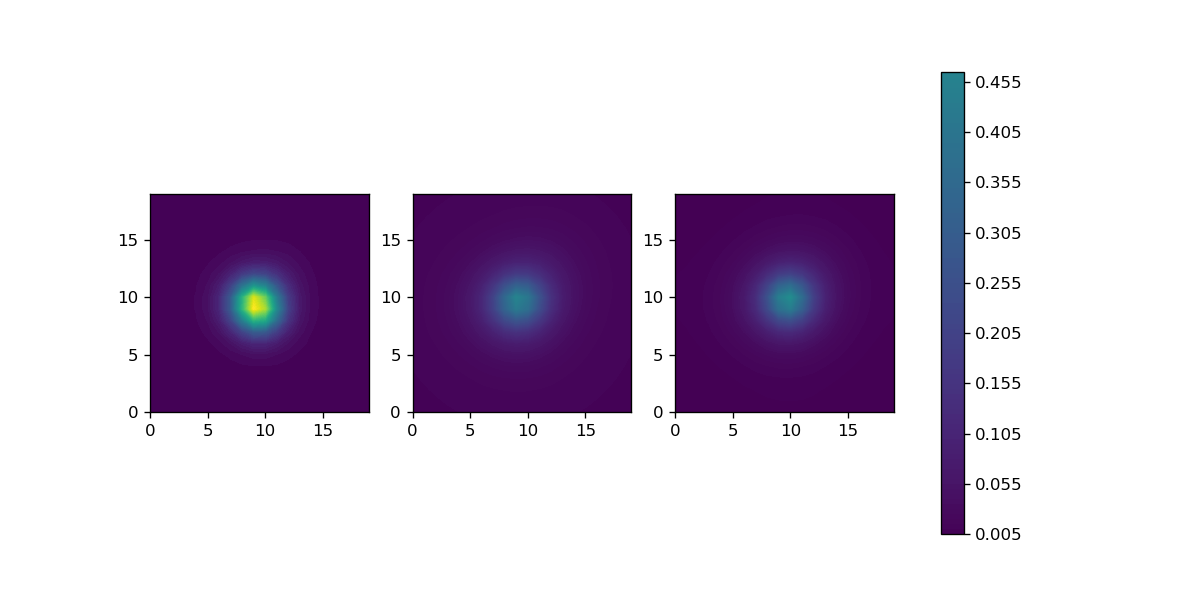

dens shape (8000,)
idx [   8  408  808 1208 1608 2008 2408 2808 3208 3608 4008 4408 4808 5208
 5608 6008 6408 6808 7208 7608   28  428  828 1228 1628 2028 2428 2828
 3228 3628 4028 4428 4828 5228 5628 6028 6428 6828 7228 7628   48  448
  848 1248 1648 2048 2448 2848 3248 3648 4048 4448 4848 5248 5648 6048
 6448 6848 7248 7648   68  468  868 1268 1668 2068 2468 2868 3268 3668
 4068 4468 4868 5268 5668 6068 6468 6868 7268 7668   88  488  888 1288
 1688 2088 2488 2888 3288 3688 4088 4488 4888 5288 5688 6088 6488 6888
 7288 7688  108  508  908 1308 1708 2108 2508 2908 3308 3708 4108 4508
 4908 5308 5708 6108 6508 6908 7308 7708  128  528  928 1328 1728 2128
 2528 2928 3328 3728 4128 4528 4928 5328 5728 6128 6528 6928 7328 7728
  148  548  948 1348 1748 2148 2548 2948 3348 3748 4148 4548 4948 5348
 5748 6148 6548 6948 7348 7748  168  568  968 1368 1768 2168 2568 2968
 3368 3768 4168 4568 4968 5368 5768 6168 6568 6968 7368 7768  188  588
  988 1388 1788 2188 2588 2988 3388 3788 4188 4588 498

In [48]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib notebook
sample = 8
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(131)
dens = np.array(valid_cube_dataset[sample]['density'].squeeze())
print('dens shape', dens.shape)
x, y  = np.meshgrid(np.arange(args.cube_size), np.arange(args.cube_size))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + np.round((args.cube_size * 0.8)/2).astype(np.int)
idx = np.ravel_multi_index((x_f, y_f, z_f), (args.cube_size, args.cube_size, args.cube_size))
                
#X, Y, Z = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38, np.arange(50) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))

print('idx', idx)
dens2d = dens[idx]
dens2d = dens2d.reshape(args.cube_size, args.cube_size)

indices = np.stack((x_f, y_f, z_f), axis=1)
coords_space = valid_cube_dataset[sample]['coords']
print('coords space shape', coords_space.shape)
vmin = np.min(dens2d)
vmax = np.max(dens2d)
c1 = ax1.contourf(x, y, dens2d, vmin=vmin, vmax=vmax, levels=100)
ax1.set_aspect('equal')

positions = valid_cube_dataset[sample]['positions']
if args.use_gpu:
    positions = positions.cuda()
    coords_space = coords_space.cuda()

print('pos shape', valid_cube_dataset[[sample]]['positions'].shape)
print('positions type', positions.type())
coeffs = equiv_model(R=positions)
pred_dens = expansion_model(coords_space, positions,
                            coeffs['spherical_coeffs'],
                            coeffs['radial_width'],
                            coeffs['radial_scale'])



print(pred_dens['density'].shape)

p_dens = pred_dens['density'].cpu().data.squeeze().numpy()
p_dens = p_dens[idx].reshape(args.cube_size, args.cube_size)

ax2 = fig.add_subplot(132)
c2 = ax2.contourf(x, y, p_dens, vmin=vmin, vmax=vmax, levels=100)
ax2.set_aspect('equal')
print('opt_dens shape', opt_dens.shape)
opt_dens = np.array(new_rho.reshape(-1)[idx].reshape(args.cube_size, args.cube_size))

ax3 = fig.add_subplot(133)
c3 = ax3.contourf(x, y, opt_dens, vmin=vmin, vmax=vmax, levels=100)
ax3.set_aspect('equal')

fig.colorbar(c2, ax=[ax1, ax2, ax3])

plt.show()